In [1]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)


Mounted at /content/drive


In [2]:
!ls /content/drive/MyDrive/Ev_charging_data

2023  2024  2025


In [3]:
import pandas as pd
import glob

base_path = "/content/drive/MyDrive/Ev_charging_data"

files = (
    glob.glob(f"{base_path}/2023/*.csv") +
    glob.glob(f"{base_path}/2024/*.csv") +
    glob.glob(f"{base_path}/2025/*.csv")
)

print("Number of files loaded:", len(files))


Number of files loaded: 36


In [4]:
#Add month & year from filename and combine
all_dfs = []

for file in files:
    df = pd.read_csv(file)

    filename = file.split("/")[-1]
    month, year = filename.replace(".csv","").split("_")

    df['month'] = int(month)
    df['year'] = int(year)

    all_dfs.append(df)

master_df = pd.concat(all_dfs, ignore_index=True)

EDA(Exploratory data amalysis)

In [5]:
master_df[['year','month']].drop_duplicates().sort_values(['year','month'])


,year,month
0,2023,1
90,2023,2
182,2023,3
282,2023,4
390,2023,5
513,2023,6
641,2023,7
774,2023,8
919,2023,9
1078,2023,10


In [6]:
#DATA QUALITY CHECK & CLEANING
master_df.info()
master_df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9018 entries, 0 to 9017
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   circle         9018 non-null   object 
 1   division       9018 non-null   object 
 2   subdivision    9018 non-null   object 
 3   section        9018 non-null   object 
 4   area           9018 non-null   object 
 5   catdesc        9018 non-null   object 
 6   catcode        9018 non-null   int64  
 7   totservices    9018 non-null   int64  
 8   billdservices  8608 non-null   float64
 9   units          9018 non-null   float64
 10  load           9018 non-null   float64
 11  month          9018 non-null   int64  
 12  year           9018 non-null   int64  
dtypes: float64(3), int64(4), object(6)
memory usage: 916.0+ KB


,catcode,totservices,billdservices,units,load,month,year
count,9018.0,9018.000000,8608.000000,9018.000000,9018.000000,9018.000000,9018.000000
mean,9.0,1.236416,1.226185,1855.061654,45.154376,6.977711,2024.348858
std,0.0,0.586337,0.568592,3444.393799,37.736167,3.374856,0.764240
min,9.0,1.000000,1.000000,-1740.000000,2.000000,1.000000,2023.000000
25%,9.0,1.000000,1.000000,3.000000,17.000000,4.000000,2024.000000
50%,9.0,1.000000,1.000000,465.000000,50.000000,7.000000,2025.000000
75%,9.0,1.000000,1.000000,2329.750000,54.000000,10.000000,2025.000000
max,9.0,6.000000,6.000000,43562.000000,336.000000,12.000000,2025.000000


In [7]:
# Remove negative consumption
master_df = master_df[master_df['units'] >= 0]

# Replace zero services to avoid division error
master_df['billdservices'] = master_df['billdservices'].replace(0, 1)

# Fill missing load with median
master_df['load'] = master_df['load'].fillna(master_df['load'].median())


In [8]:
#REMOVE INVALID RECORDS(Records with zero consumption, zero services, or zero connected load were removed to avoid invalid utilization ratios and misleading demand estimates.)
# Remove invalid rows
master_df = master_df[
    (master_df['units'] > 0) &
    (master_df['billdservices'] > 0) &
    (master_df['load'] > 0)
].reset_index(drop=True)


In [9]:
#OUTLIER HANDLING USING IQR
def cap_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[column] = df[column].clip(lower, upper)
    return df

In [10]:
#Applying it to key numerical columns
for col in ['units', 'billdservices', 'load']:
    master_df = cap_outliers_iqr(master_df, col)

In [11]:
#Remove rows with suspicious utilization
# Preliminary utilization check
master_df['temp_util'] = master_df['units'] / master_df['load']

master_df = master_df[
    (master_df['temp_util'] > 0) &
    (master_df['temp_util'] < master_df['temp_util'].quantile(0.99))
]

master_df.drop(columns=['temp_util'], inplace=True)


In [12]:
master_df.describe()

,catcode,totservices,billdservices,units,load,month,year
count,6876.0,6876.000000,6876.0,6876.000000,6876.000000,6876.000000,6876.000000
mean,9.0,1.273560,1.0,1987.476840,43.543016,6.926702,2024.303810
std,0.0,0.635945,0.0,2245.587325,30.104122,3.413919,0.764326
min,9.0,1.000000,1.0,1.000000,2.000000,1.000000,2023.000000
25%,9.0,1.000000,1.0,213.000000,18.000000,4.000000,2024.000000
50%,9.0,1.000000,1.0,1081.000000,45.000000,7.000000,2024.000000
75%,9.0,1.000000,1.0,2959.500000,54.000000,10.000000,2025.000000
max,9.0,6.000000,1.0,7263.250000,108.000000,12.000000,2025.000000


In [13]:
#CREATE DERIVED METRICS
master_df['units_per_service'] = master_df['units'] / master_df['billdservices']
master_df['load_utilization'] = master_df['units'] / master_df['load']


In [14]:
#COMBINING YEAR-WISE DATA (FOR ANALYSIS)
yearly_demand = master_df.groupby('year')['units'].sum().reset_index()
yearly_demand

,year,units
0,2023,1267898.00
1,2024,4052619.75
2,2025,8345373.00


In [15]:
#Year + Month-wise demand (time series)
monthly_demand = master_df.groupby(['year','month'])['units'].sum().reset_index()


In [16]:
#Year + Division-wise demand
year_division_demand = master_df.groupby(['year','division'])['units'].sum().reset_index()


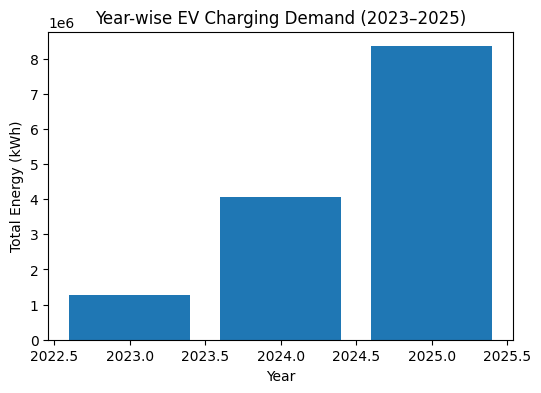

In [17]:
#Year-wise demand trend
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.bar(yearly_demand['year'], yearly_demand['units'])
plt.xlabel("Year")
plt.ylabel("Total Energy (kWh)")
plt.title("Year-wise EV Charging Demand (2023–2025)")
plt.show()


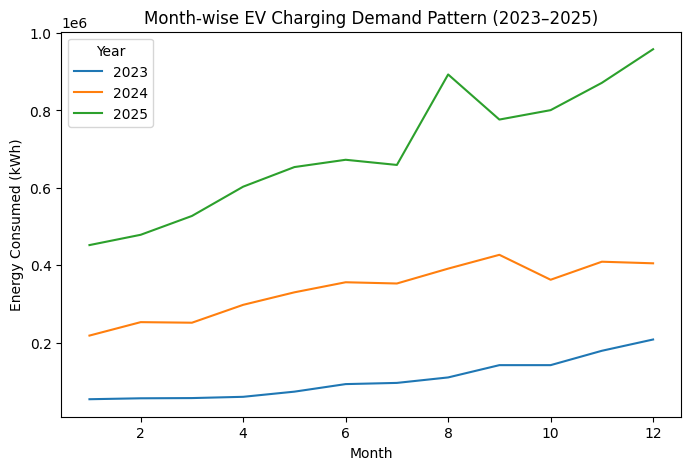

In [18]:
#Month-wise demand pattern
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

for year in monthly_demand['year'].unique():
    data = monthly_demand[monthly_demand['year'] == year]
    plt.plot(data['month'], data['units'], label=str(year))

plt.xlabel("Month")
plt.ylabel("Energy Consumed (kWh)")
plt.title("Month-wise EV Charging Demand Pattern (2023–2025)")
plt.legend(title="Year")
plt.show()


In [19]:
#Area-wise demand
area_demand = master_df.groupby('division')['units'].sum().reset_index()

In [20]:
area_demand.sort_values('units', ascending=False)



,division,units
10,GACHIBOWLI,1160051.25
38,SAROORNAGAR,1046765.00
36,SAINIKPURI,868575.75
2,BANJARA HILLS,793252.75
14,HABSIGUDA,764347.25
24,KUKATPALLY,705052.50
23,KONDAPUR,574106.50
34,RAJENDRA NAGAR,573801.50
35,SAIFABAD,556997.50
32,PARADISE,508516.50


In [21]:
circle_demand = master_df.groupby('circle')['units'].sum().reset_index()
circle_demand

,circle,units
0,BANJARA HILLS,1238883.50
1,CYBERCITY,1962105.25
2,GADWAL,146786.50
3,HABSIGUDA,1651230.00
4,HYDERABAD CENTRAL,1089784.25
5,HYDERABAD SOUTH,430170.25
6,MAHABOOBNAGAR,350071.25
7,MEDAK,22062.00
8,MEDCHAL,1284400.25
9,NAGARKURNOOL,129357.25


In [22]:
subdivision_demand = master_df.groupby('subdivision')['units'].sum().reset_index()
subdivision_demand

,subdivision,units
0,A S RAO NAGAR,342530.50
1,A.C.GUARDS,19424.00
2,ACHAMPET,30679.00
3,ALAMPUR X ROAD,146786.50
4,ALER,19.00
...,...,...
102,UPPAL,343701.25
103,VANASTHALIPURAM,315624.00
104,VEMULAPALLY,23602.00
105,WANAPARTHY,262.00


DIAGNOSTIC ANALYTICS

In [23]:
master_df[['units', 'load']].corr()


,units,load
units,1.000000,0.424263
load,0.424263,1.000000


In [24]:
#STATION / AREA CLASSIFICATION
q1 = master_df['units'].quantile(0.25)
q3 = master_df['units'].quantile(0.75)

def classify(u):
    if u > q3:
        return "High Demand"
    elif u < q1:
        return "Low Demand"
    else:
        return "Moderate Demand"

master_df['demand_category'] = master_df['units'].apply(classify)
master_df

,circle,division,subdivision,section,area,catdesc,catcode,totservices,billdservices,units,load,month,year,units_per_service,load_utilization,demand_category
0,BANJARA HILLS,GREEN LANDS,GREENLANDS,BEGUMPET,GRC. SHYAMLAL,EV CHARGING STATIONS,9,1,1.0,1246.00,22.0,1,2023,1246.00,56.636364,Moderate Demand
1,BANJARA HILLS,GREEN LANDS,GREENLANDS,GREENLANDS,GRC HV GREENLANDS,EV CHARGING STATIONS,9,1,1.0,227.00,10.0,1,2023,227.00,22.700000,Moderate Demand
2,BANJARA HILLS,BANJARA HILLS,AMEERPET,YOUSUFGUDA,PRAGATHINAGAR-1,EV CHARGING STATIONS,9,1,1.0,216.00,8.0,1,2023,216.00,27.000000,Moderate Demand
3,BANJARA HILLS,BANJARA HILLS,BANJARA HILLS,FILM NAGAR,"CHURCH GULLY,MLA COLONY,APOLO",EV CHARGING STATIONS,9,1,1.0,1282.00,55.0,1,2023,1282.00,23.309091,Moderate Demand
4,BANJARA HILLS,BANJARA HILLS,JUBILEE HILLS,JUBILEE HILLS,GRC HIGH VALUES,EV CHARGING STATIONS,9,1,1.0,31.00,15.0,1,2023,31.00,2.066667,Low Demand
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6941,YADADRI,CHOUTUPPAL,CHOUTUPPAL,CHOUTUPPAL,TOOFRAN PET,EV CHARGING STATIONS,9,2,1.0,203.00,108.0,12,2025,203.00,1.879630,Low Demand
6942,YADADRI,BHONGIR,BHONGIR,BHONGIR _ RURAL,RAIGIR,EV CHARGING STATIONS,9,5,1.0,7263.25,108.0,12,2025,7263.25,67.252315,High Demand
6943,YADADRI,BHONGIR,BHONGIR,BHONGIR _ RURAL,WADAIGUDEM,EV CHARGING STATIONS,9,1,1.0,435.00,55.0,12,2025,435.00,7.909091,Moderate Demand
6944,YADADRI,BHONGIR,BHONGIR,BHONGIR - TOWN,BHONGIR(T),EV CHARGING STATIONS,9,1,1.0,1144.00,54.0,12,2025,1144.00,21.185185,Moderate Demand



GROWING DEMAND PREDICTION

In [25]:
#DEMAND FORECASTING (HOLT–WINTERS)
# Create proper date column
master_df['date'] = pd.to_datetime(
    master_df['year'].astype(str) + '-' +
    master_df['month'].astype(str) + '-01'
)

# Aggregate to monthly demand (state-level)
monthly_demand = (
    master_df
    .groupby('date')['units']
    .sum()
    .reset_index()
    .sort_values('date')
)

monthly_demand.set_index('date', inplace=True)
monthly_demand.head()


,units
date,
2023-01-01,53627.00
2023-02-01,56018.00
2023-03-01,56586.00
2023-04-01,59854.00
2023-05-01,73193.25


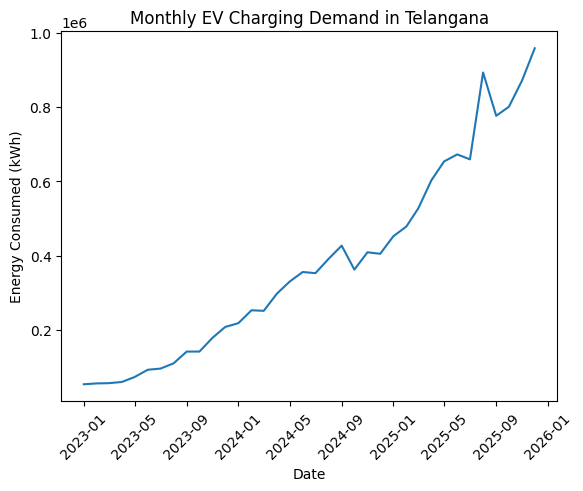

In [26]:
#Visualize historical demand
import matplotlib.pyplot as plt

plt.figure()
plt.plot(monthly_demand.index, monthly_demand['units'])
plt.title('Monthly EV Charging Demand in Telangana')
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.ylabel('Energy Consumed (kWh)')
plt.show()


In [27]:
#rain Holt–Winters Model
from statsmodels.tsa.holtwinters import ExponentialSmoothing

hw_model = ExponentialSmoothing(
    monthly_demand['units'],
    trend='add',
    seasonal=None
)

hw_fit = hw_model.fit()


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [28]:
#Forecast Future Demand (NEXT 12 MONTHS)
forecast_horizon = 12

forecast = hw_fit.forecast(forecast_horizon)

forecast_dates = pd.date_range(
    start=monthly_demand.index[-1] + pd.offsets.MonthBegin(),
    periods=forecast_horizon,
    freq='MS'
)

forecast_df = pd.DataFrame({
    'date': forecast_dates,
    'forecast_units': forecast.values
})

forecast_df


,date,forecast_units
0,2026-01-01,9.741099e+05
1,2026-02-01,1.016993e+06
2,2026-03-01,1.059875e+06
3,2026-04-01,1.102758e+06
4,2026-05-01,1.145640e+06
5,2026-06-01,1.188523e+06
6,2026-07-01,1.231405e+06
7,2026-08-01,1.274288e+06
8,2026-09-01,1.317171e+06
9,2026-10-01,1.360053e+06


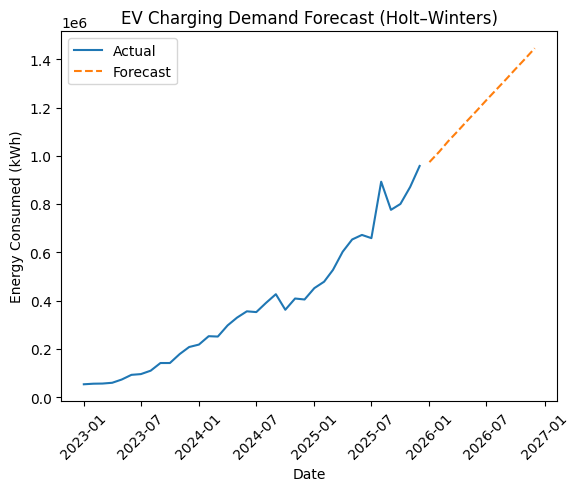

In [29]:
#Plot Actual vs Forecast
plt.figure()
plt.plot(monthly_demand.index, monthly_demand['units'], label='Actual')
plt.plot(forecast_df['date'], forecast_df['forecast_units'],
         label='Forecast', linestyle='--')

plt.title('EV Charging Demand Forecast (Holt–Winters)')
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.ylabel('Energy Consumed (kWh)')
plt.legend()
plt.show()


In [30]:
#Model Evaluation using MAPE
from sklearn.metrics import mean_absolute_percentage_error
test_horizon = 3

train = monthly_demand.iloc[:-test_horizon]['units']
test  = monthly_demand.iloc[-test_horizon:]['units']


hw_eval_model = ExponentialSmoothing(
    train,
    trend='add',
    seasonal=None
).fit()
test_forecast = hw_eval_model.forecast(test_horizon)


mape = mean_absolute_percentage_error(test, test_forecast) * 100
print(f"MAPE: {mape:.2f}%")

MAPE: 6.49%


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [31]:
for h in [3, 6, 9]:
    train = monthly_demand.iloc[:-h]['units']
    test  = monthly_demand.iloc[-h:]['units']

    model = ExponentialSmoothing(
        train,
        trend='add',
        seasonal=None
    ).fit()

    forecast = model.forecast(h)

    mape = mean_absolute_percentage_error(test, forecast) * 100
    print(f"{h}-Month Horizon MAPE: {mape:.2f}%")


3-Month Horizon MAPE: 6.49%
6-Month Horizon MAPE: 6.16%
9-Month Horizon MAPE: 19.91%


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


PHASE 3

In [32]:
#DIVISION-LEVEL AGGREGATION
area_df = master_df.groupby('division').agg({
    'units': 'sum',
    'billdservices': 'sum',
    'load': 'mean'
}).reset_index()

area_df.head()

,division,units,billdservices,load
0,ASMANGADH,99286.00,50.0,35.560000
1,AZAMABAD,115059.00,98.0,41.275510
2,BANJARA HILLS,793252.75,271.0,51.505535
3,BEGUM BAZAR,106828.00,82.0,32.731707
4,BHONGIR,227567.25,101.0,70.930693


In [33]:
#CORE INDICATORS
# Current demand intensity
area_df['demand_per_service'] = area_df['units'] / area_df['billdservices']

# Grid stress indicator
area_df['load_utilization'] = area_df['units'] / area_df['load']

In [34]:
#FUTURE DEMAND ALLOCATION
# Division-wise demand share
area_df['demand_share'] = area_df['units'] / area_df['units'].sum()

# Total forecasted demand
total_future_demand = forecast_df['forecast_units'].sum()

# Allocate future demand to divisions
area_df['future_demand'] = area_df['demand_share'] * total_future_demand

In [35]:
#REALISTIC CURRENT EV STATION ESTIMATION
import numpy as np
EV_STATION_RATIO = 0.05  # 5% of services assumed as EV charging points

area_df['current_stations'] = (
    area_df['billdservices'] * EV_STATION_RATIO
).apply(np.ceil)

In [36]:
#PEAK DEMAND ADJUSTMENT
PEAK_FACTOR = 1.3  # 30% peak margin

area_df['effective_future_demand'] = area_df['future_demand'] * PEAK_FACTOR

In [37]:
#CAPACITY & REQUIRED STATIONS MODEL
AVG_STATION_CAPACITY = 40000   # kWh/year/station
TARGET_UTILIZATION = 0.75     # Optimal utilization

area_df['required_stations'] = (
    area_df['effective_future_demand'] /
    (AVG_STATION_CAPACITY * TARGET_UTILIZATION)
).apply(np.ceil)

In [38]:
#ADDITIONAL STATIONS REQUIRED
area_df['additional_stations_required'] = (
    area_df['required_stations'] - area_df['current_stations']
)

area_df['additional_stations_required'] = (
    area_df['additional_stations_required']
    .clip(lower=0)
    .astype(int)
)

In [39]:
#PROFIT FEASIBILITY LABEL
TARIFF = 6  # Rs/kWh (Telangana avg)

area_df['estimated_revenue'] = area_df['future_demand'] * TARIFF

profit_threshold = area_df['estimated_revenue'].median()

area_df['profit_feasible'] = (
    area_df['estimated_revenue'] >= profit_threshold
).astype(int)

In [40]:
#MACHINE LEARNING (RANDOM FOREST)
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score


In [41]:
#Feature set
X = area_df[['effective_future_demand', 'load_utilization']]
y = area_df['profit_feasible']

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [42]:
#Train & validate
rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=3,
    min_samples_leaf=3,
    random_state=42
)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

scores = cross_val_score(
    rf,
    X_scaled,
    y,
    cv=cv,
    scoring='f1_weighted'
)

print("Mean F1 score:", scores.mean())

Mean F1 score: 0.9790849673202615


In [43]:
#FINAL MODEL & PROFIT PROBABILITY
rf.fit(X_scaled, y)

area_df['profit_probability'] = rf.predict_proba(X_scaled)[:, 1]

In [44]:
#FINAL RESULT TABLE
final_output = area_df[
    [
        'division',
        'future_demand',
        'current_stations',
        'additional_stations_required',
        'profit_probability'
    ]
].sort_values(
    by=['additional_stations_required', 'profit_probability'],
    ascending=False
)

final_output.head(50)

,division,future_demand,current_stations,additional_stations_required,profit_probability
10,GACHIBOWLI,1.232517e+06,17.0,37,1.000000
38,SAROORNAGAR,1.112154e+06,24.0,25,1.000000
2,BANJARA HILLS,8.428055e+05,14.0,23,1.000000
24,KUKATPALLY,7.490956e+05,14.0,19,1.000000
14,HABSIGUDA,8.120944e+05,18.0,18,1.000000
35,SAIFABAD,5.917919e+05,8.0,18,1.000000
23,KONDAPUR,6.099697e+05,10.0,17,1.000000
34,RAJENDRA NAGAR,6.096456e+05,11.0,16,1.000000
36,SAINIKPURI,9.228338e+05,24.0,16,1.000000
28,MEHDIPATNAM,4.438223e+05,6.0,14,1.000000


In [45]:
#INTERACTIVE DIVISION QUERY (USER INPUT)
def recommend_ev_stations(division_name, df):
    division_name = division_name.strip().lower()
    df_copy = df.copy()
    df_copy['division_lower'] = df_copy['division'].str.lower()

    if division_name not in df_copy['division_lower'].values:
        print("❌ Division not found.")
        print("Available divisions:")
        for d in sorted(df['division'].unique()):
            print("-", d)
        return

    row = df_copy[df_copy['division_lower'] == division_name].iloc[0]

    print("\n======================================")
    print(" EV CHARGING STATION RECOMMENDATION ")
    print("======================================")
    print(f"Division                     : {row['division']}")
    print(f"Forecasted Charging Demand   : {row['future_demand']:.0f} kWh")
    print(f"Existing EV Stations         : {int(row['current_stations'])}")
    print(f"Additional Stations Needed   : {int(row['additional_stations_required'])}")
    print(f"Profit Feasibility Probability: {row['profit_probability']:.2f}")

    if row['additional_stations_required'] == 0:
        print("Recommendation               : Current infrastructure is sufficient.")
    else:
        print("Recommendation               : Install additional EV charging stations.")

    print("======================================")


In [46]:
division_input = input("Enter the division name to check EV charging station requirement: ")
recommend_ev_stations(division_input, area_df)

Enter the division name to check EV charging station requirement: AZAMABAD

 EV CHARGING STATION RECOMMENDATION 
Division                     : AZAMABAD
Forecasted Charging Demand   : 122246 kWh
Existing EV Stations         : 5
Additional Stations Needed   : 1
Profit Feasibility Probability: 0.00
Recommendation               : Install additional EV charging stations.


In [47]:
#EXPORT TIME-SERIES DEMAND
# Prepare time-series demand table
timeseries_df = monthly_demand.reset_index()
timeseries_df.columns = ['date', 'total_charging_demand_kwh']

# Save to CSV
timeseries_df.to_csv("TimeSeries_Demand.csv", index=False)

print("✅ TimeSeries_Demand.csv created")

✅ TimeSeries_Demand.csv created


In [48]:
#EXPORT DIVISION SUMMARY
division_summary_df = final_output.copy()

division_summary_df.to_csv("Division_Summary.csv", index=False)

print("✅ Division_Summary.csv created")


✅ Division_Summary.csv created


In [49]:
#EXPORT DIVISION DIAGNOSTICS
division_diagnostics_df = area_df[
    [
        'division',
        'demand_per_service',
        'load_utilization',
        'estimated_revenue'
    ]
].copy()

division_diagnostics_df.to_csv("Division_Diagnostics.csv", index=False)

print("✅ Division_Diagnostics.csv created")

✅ Division_Diagnostics.csv created


In [50]:
#EXPORT FUTURE FORECAST
forecast_df.to_csv("Future_Demand_Forecast.csv", index=False)

print("✅ Future_Demand_Forecast.csv created")


✅ Future_Demand_Forecast.csv created


In [51]:
#DOWNLOAD CSV FILES FROM COLAB
from google.colab import files
#files.download("TimeSeries_Demand.csv")
#files.download("Division_Summary.csv")
#files.download("Division_Diagnostics.csv")
#files.download("Future_Demand_Forecast.csv")



PHASE 4: Exploratory Dashboards (HTML)

In [52]:
!pip install ydata-profiling


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 62.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 39.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 6.0 MB/s eta 0:00:00


In [53]:
import pandas as pd
from ydata_profiling import ProfileReport


/tmp/ipykernel_6216/1122806291.py:2: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


In [54]:
#PAGE 1: Demand Overview (State Level)
state_level_df = master_df[[
    'year',
    'month',
    'units',
    'load',
    'billdservices'
]]

profile_state = ProfileReport(
    state_level_df,
    title="PAGE 1: State-Level EV Charging Demand Overview (Telangana)",
    explorative=True
)

profile_state.to_file("PAGE1_State_Demand_Overview.html")

/usr/local/lib/python3.12/dist-packages/ydata_profiling/utils/dataframe.py:137: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns={"index": "df_index"}, inplace=True)


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 5/5 [00:00<00:00, 73.79it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [55]:
#PAGE 2: Division-wise Demand & Infrastructure
division_demand_df = area_df[[
    'division',
    'units',
    'load',
    'billdservices',
    'demand_per_service',
    'load_utilization'
]]

profile_division = ProfileReport(
    division_demand_df,
    title="PAGE 2: Division-wise Demand & Infrastructure Analysis",
    explorative=True
)

profile_division.to_file("PAGE2_Division_Demand_Infrastructure.html")


/usr/local/lib/python3.12/dist-packages/ydata_profiling/utils/dataframe.py:137: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns={"index": "df_index"}, inplace=True)


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 6/6 [00:00<00:00, 33.86it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [56]:
#PAGE 3: Infrastructure Gap Analysis
gap_analysis_df = final_output[[
    'division',
    'future_demand',
    'current_stations',
    'additional_stations_required'
]]

profile_gap = ProfileReport(
    gap_analysis_df,
    title="PAGE 3: Infrastructure Gap Analysis (Core Planning Page)",
    explorative=True
)

profile_gap.to_file("PAGE3_Infrastructure_Gap_Analysis.html")


/usr/local/lib/python3.12/dist-packages/ydata_profiling/utils/dataframe.py:137: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns={"index": "df_index"}, inplace=True)


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 4/4 [00:00<00:00, 100.06it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [57]:
#PAGE 4: Profit Feasibility Analysis
# ===============================
# CREATE MISSING PROFIT FEATURES
# ===============================

# 1. Units per service (charging intensity)
area_df['units_per_service'] = area_df['units'] / area_df['billdservices']

# 2. EV proxy (relative EV adoption per division)
total_ev_ts = 300000   # Telangana EV estimate (documented assumption)

area_df['ev_proxy'] = (
    area_df['units'] / area_df['units'].sum()
) * total_ev_ts

# Safety check
area_df[['division', 'units_per_service', 'ev_proxy']].head()

,division,units_per_service,ev_proxy
0,ASMANGADH,1985.720000,2179.572524
1,AZAMABAD,1174.071429,2525.828768
2,BANJARA HILLS,2927.131919,17413.853905
3,BEGUM BAZAR,1302.780488,2345.138022
4,BHONGIR,2253.141089,4995.662284


In [58]:
profit_df = area_df[
    [
        'division',
        'estimated_revenue',
        'units_per_service',
        'load_utilization',
        'ev_proxy'
    ]
]

profile_profit = ProfileReport(
    profit_df,
    title="PAGE 4: Profit Feasibility Analysis of EV Charging Infrastructure",
    explorative=True
)

profile_profit.to_file("PAGE4_Profit_Feasibility_Analysis.html")

/usr/local/lib/python3.12/dist-packages/ydata_profiling/utils/dataframe.py:137: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns={"index": "df_index"}, inplace=True)


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 5/5 [00:00<00:00, 102.45it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [59]:
#PAGE 5: Geographic Planning
geo_planning_df = area_df[[
    'division',
    'units',
    'future_demand',
    'additional_stations_required'
]]

profile_geo = ProfileReport(
    geo_planning_df,
    title="PAGE 5: Geographic Planning Support for EV Charging Stations",
    explorative=True
)

profile_geo.to_file("PAGE5_Geographic_Planning.html")

/usr/local/lib/python3.12/dist-packages/ydata_profiling/utils/dataframe.py:137: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns={"index": "df_index"}, inplace=True)


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 4/4 [00:00<00:00, 133.29it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [60]:
from IPython.display import FileLink, display

display(FileLink("PAGE1_State_Demand_Overview.html"))
display(FileLink("PAGE2_Division_Demand_Infrastructure.html"))
display(FileLink("PAGE3_Infrastructure_Gap_Analysis.html"))
display(FileLink("PAGE4_Profit_Feasibility_Analysis.html"))
display(FileLink("PAGE5_Geographic_Planning.html"))


/content/PAGE1_State_Demand_Overview.html

/content/PAGE2_Division_Demand_Infrastructure.html

/content/PAGE3_Infrastructure_Gap_Analysis.html

/content/PAGE4_Profit_Feasibility_Analysis.html

/content/PAGE5_Geographic_Planning.html

In [61]:
from IPython.display import HTML, display

display(HTML(filename="PAGE1_State_Demand_Overview.html"))


In [62]:
import pickle

with open("demand_model.pkl", "wb") as f:
    pickle.dump(hw_fit, f)

In [63]:
import pickle
import numpy as np

class InfrastructureRequirementModel:

    def __init__(self, avg_station_capacity, target_utilization, peak_factor, ev_station_ratio):
        self.avg_station_capacity = avg_station_capacity
        self.target_utilization = target_utilization
        self.peak_factor = peak_factor
        self.ev_station_ratio = ev_station_ratio

    def predict(self, future_demand, billed_services):
        """
        Predict additional stations required
        """
        # Estimate current stations
        current_stations = np.ceil(billed_services * self.ev_station_ratio)

        # Apply peak demand adjustment
        effective_future_demand = future_demand * self.peak_factor

        # Calculate required stations
        required_stations = np.ceil(
            effective_future_demand /
            (self.avg_station_capacity * self.target_utilization)
        )

        additional_stations = required_stations - current_stations

        if additional_stations < 0:
            additional_stations = 0

        return {
            "current_stations": int(current_stations),
            "required_stations": int(required_stations),
            "additional_stations_required": int(additional_stations)
        }

In [64]:
AVG_STATION_CAPACITY = 40000
TARGET_UTILIZATION = 0.75
PEAK_FACTOR = 1.3
EV_STATION_RATIO = 0.05

infra_model = InfrastructureRequirementModel(
    avg_station_capacity=AVG_STATION_CAPACITY,
    target_utilization=TARGET_UTILIZATION,
    peak_factor=PEAK_FACTOR,
    ev_station_ratio=EV_STATION_RATIO
)

In [65]:
with open("infrastructure_model.pkl", "wb") as f:
    pickle.dump(infra_model, f)

print("✅ infrastructure_model.pkl file created successfully")

✅ infrastructure_model.pkl file created successfully


In [66]:
#from google.colab import files
#files.download("infrastructure_model.pkl")